## Simple Poisson Solver

## Visualizating the results

Below we give some python code to visualizate the solution using yt:

In [1]:
import yt
from yt.frontends import boxlib
from yt.frontends.boxlib.data_structures import AMReXDataset
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy as sp

N = 256
N2 = N // 2

/tmp/ipykernel_8111/3325034126.py:3: DeprecationWarning: The historic 'boxlib' frontend is 
deprecated as it has been renamed 'amrex'. Existing and future work should instead reference the 'amrex' frontend.
Deprecated since yt 4.4.0
  from yt.frontends.boxlib.data_structures import AMReXDataset


In [2]:
ls

 animate_gaus.ipynb             plt00000_Slice_x_Edens.png
 animate_pot.ipynb              plt00000_Slice_x_PhiGrav.png
 animate_slice.ipynb            plt00000_Slice_z_density.png
 animate_vol.ipynb              plt00000_Slice_z_Edens.png
 CalcGrad.ipynb                 plt00000_Slice_z_PhiGrav.png
'density weird.png'             profiles.ipynb
 ExtrapolateA.ipynb             SplitEnergies.ipynb
 NumericalSolver.ipynb          Untitled.ipynb
 Phase_plot.ipynb               Visualization.ipynb
 plt00000_Slice_x_density.png


### Energy Density

In [3]:
ds = AMReXDataset("../Outputs/plt00000")

yt : [INFO     ] 2026-07-29 11:08:18,444 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-07-29 11:08:18,445 Parameters: domain_dimensions         = [512 512 512]
yt : [INFO     ] 2026-07-29 11:08:18,445 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-29 11:08:18,447 Parameters: domain_right_edge         = [80. 80. 80.]


In [4]:
ds.field_list

[('boxlib', 'Edens'),
 ('boxlib', 'KGf'),
 ('boxlib', 'KGfVpr'),
 ('boxlib', 'KGfdens'),
 ('boxlib', 'KGfpr'),
 ('boxlib', 'KGfv'),
 ('boxlib', 'PhiGrav'),
 ('boxlib', 'PhiGravv'),
 ('boxlib', 'density')]

yt : [INFO     ] 2026-07-29 11:08:36,277 xlim = 0.000000 80.000000
yt : [INFO     ] 2026-07-29 11:08:36,277 ylim = 0.000000 80.000000
yt : [INFO     ] 2026-07-29 11:08:36,278 xlim = 0.000000 80.000000
yt : [INFO     ] 2026-07-29 11:08:36,279 ylim = 0.000000 80.000000
yt : [INFO     ] 2026-07-29 11:08:36,279 Making a fixed resolution buffer of (('boxlib', 'Edens')) 800 by 800



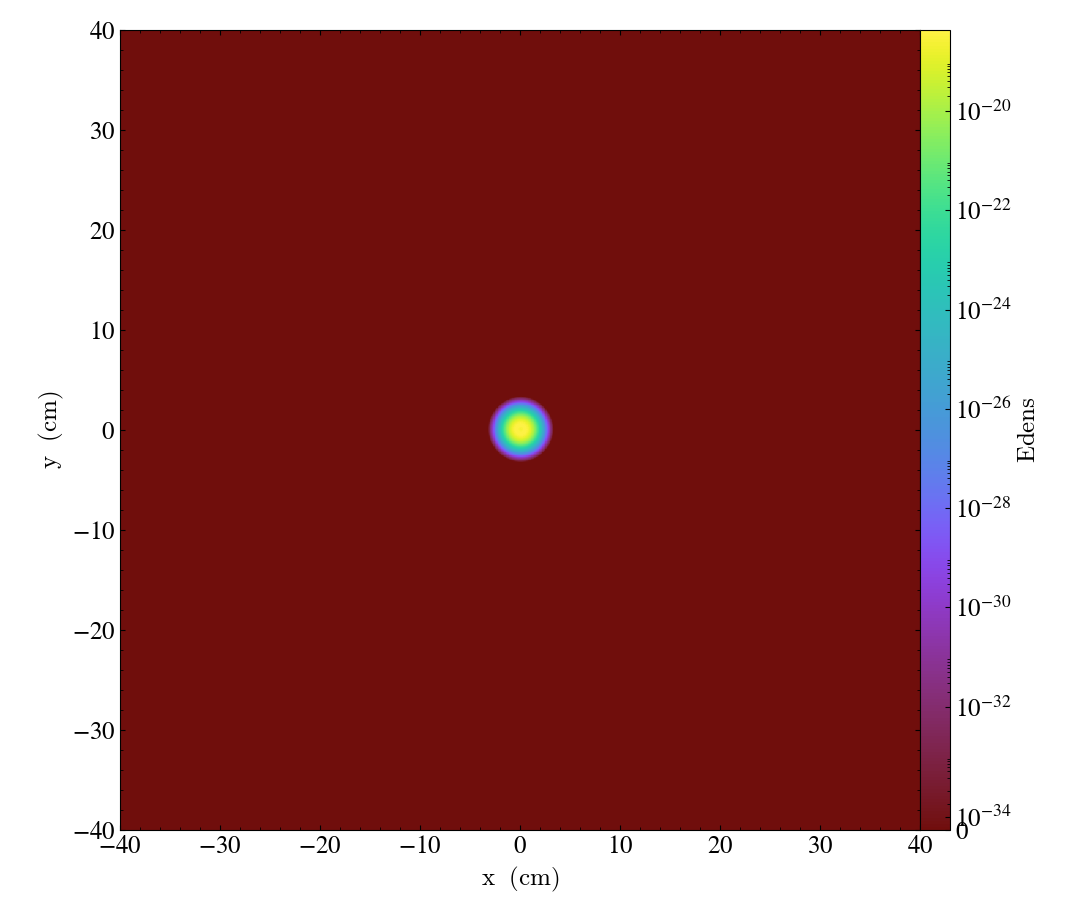

In [7]:
sl = yt.SlicePlot(ds, 2, ('boxlib', 'Edens'))
sl


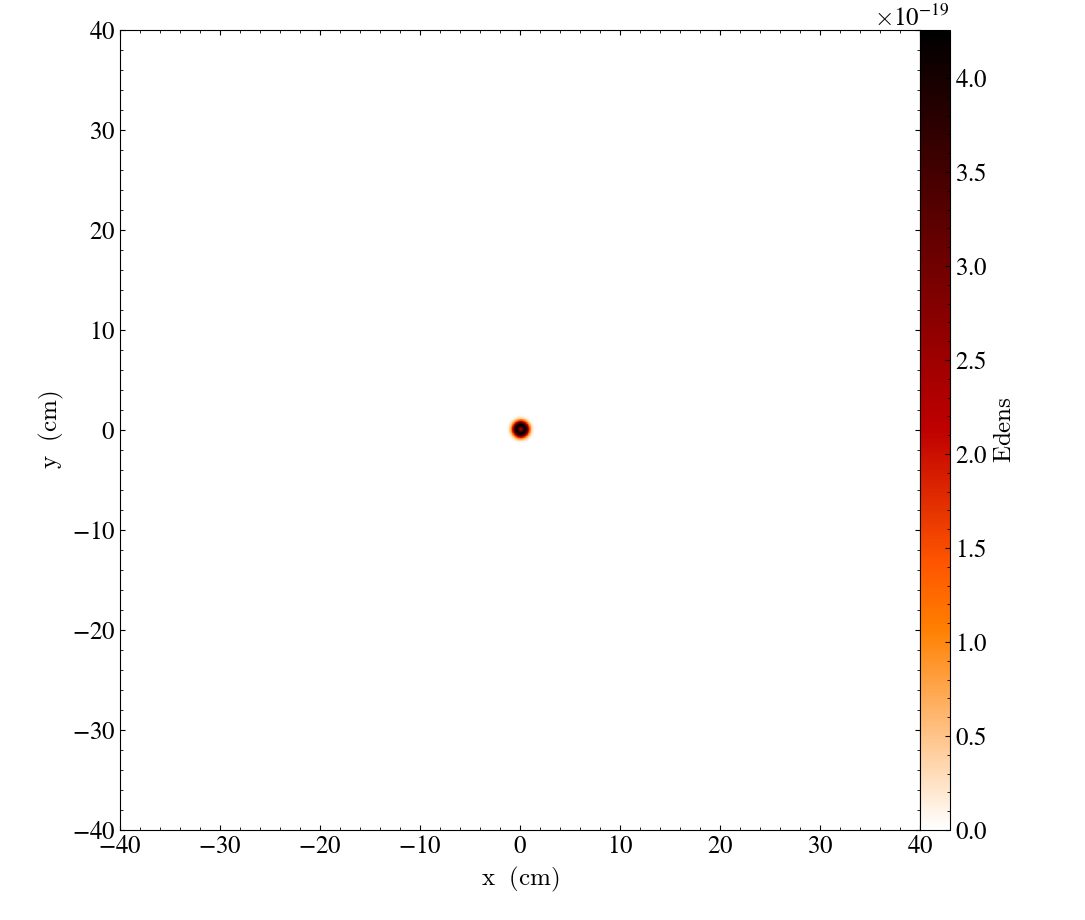

In [8]:
sl.set_log("Edens",False)
sl.set_cmap(("Edens"), "gist_heat_r")
sl

In [25]:
sl.save()

yt : [INFO     ] 2026-06-16 13:51:20,574 Saving plot plt00000_Slice_z_Edens.png


['plt00000_Slice_z_Edens.png']

### Newtonian Potential

yt : [INFO     ] 2026-07-28 18:33:14,115 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-07-28 18:33:14,116 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-07-28 18:33:14,120 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-07-28 18:33:14,120 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-07-28 18:33:14,121 Making a fixed resolution buffer of (('boxlib', 'PhiGrav')) 800 by 800



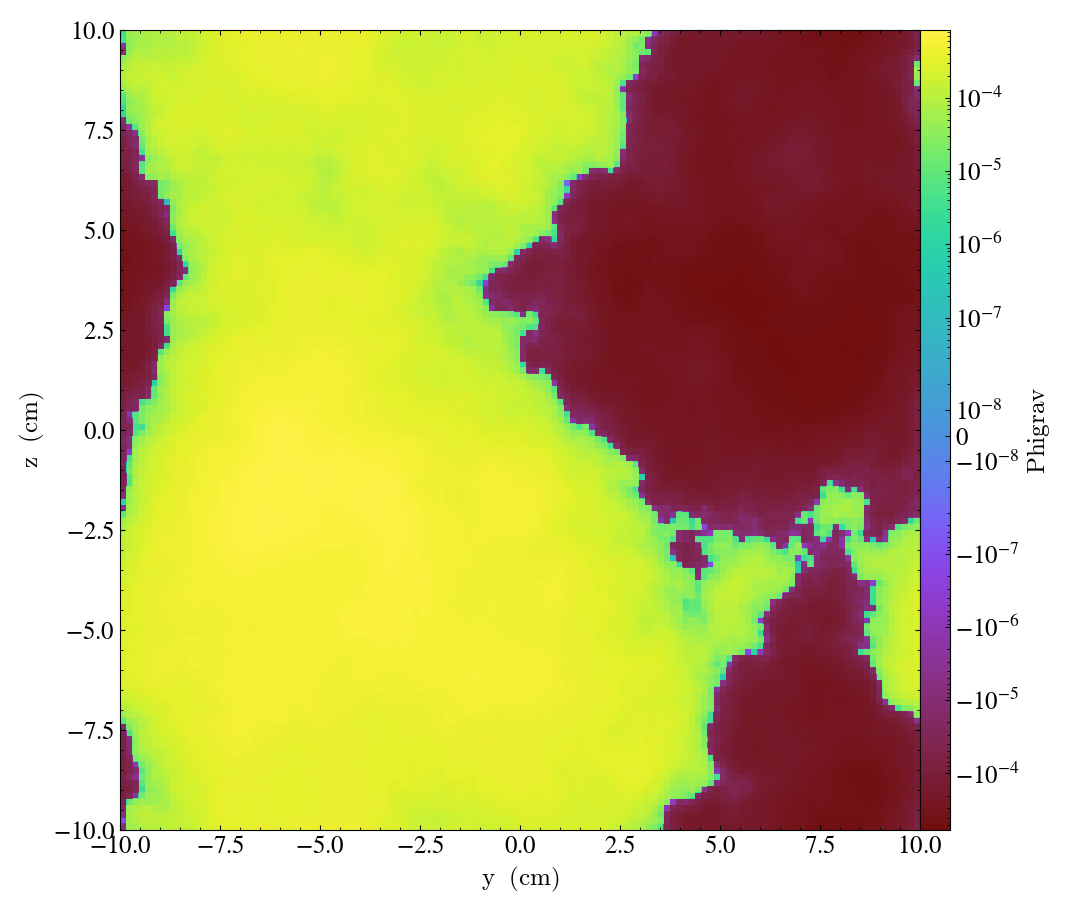

In [60]:
sl2 = yt.SlicePlot(ds, 0, ('boxlib', 'PhiGrav'))
sl2

In [25]:
all_data_level_0 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])
print(all_data_level_0["boxlib","PhiGrav"][0,0,:])
PhiGrav = all_data_level_0["boxlib","PhiGrav"]
print(PhiGrav.max()-PhiGrav.min())

[ 1.13109799e-20  1.03326627e-21  1.66923619e-20  1.69790707e-20
 -3.18138338e-22  8.64426357e-21 -2.41538279e-21 -9.96825208e-22
 -1.01122803e-20  1.47938886e-21 -7.92865125e-21  1.00381856e-20
 -4.47690094e-21  3.30601479e-22  2.23507637e-20  3.65446981e-21
 -2.43761372e-21  1.97300589e-20 -4.87480641e-21 -1.27775529e-22
  1.15045376e-20  9.64036375e-22  8.58381286e-21 -3.93885541e-21
  7.27275515e-21  7.19514187e-21  1.26813528e-20  1.27222176e-20
  1.78458594e-20 -7.51023120e-21  9.03397556e-21  1.41954794e-20
  5.36352274e-21  4.00809158e-21 -5.13875618e-21 -8.02875698e-21
 -9.81350103e-21  6.03743976e-21  1.74506293e-20 -2.23682020e-21
  2.56370573e-20  1.17016985e-20  1.68815549e-20 -1.45462488e-20
 -5.66379490e-21 -3.50463628e-21 -5.12922497e-21 -5.11566448e-21
  5.78635427e-21 -1.59208667e-21 -3.38345305e-21 -6.53599268e-21
 -6.28097454e-21 -1.04445870e-20 -6.86233722e-21  8.67112139e-22
 -1.00494187e-20 -3.61667190e-21  1.88001226e-20  2.55328480e-21
  1.20024710e-20  1.04374


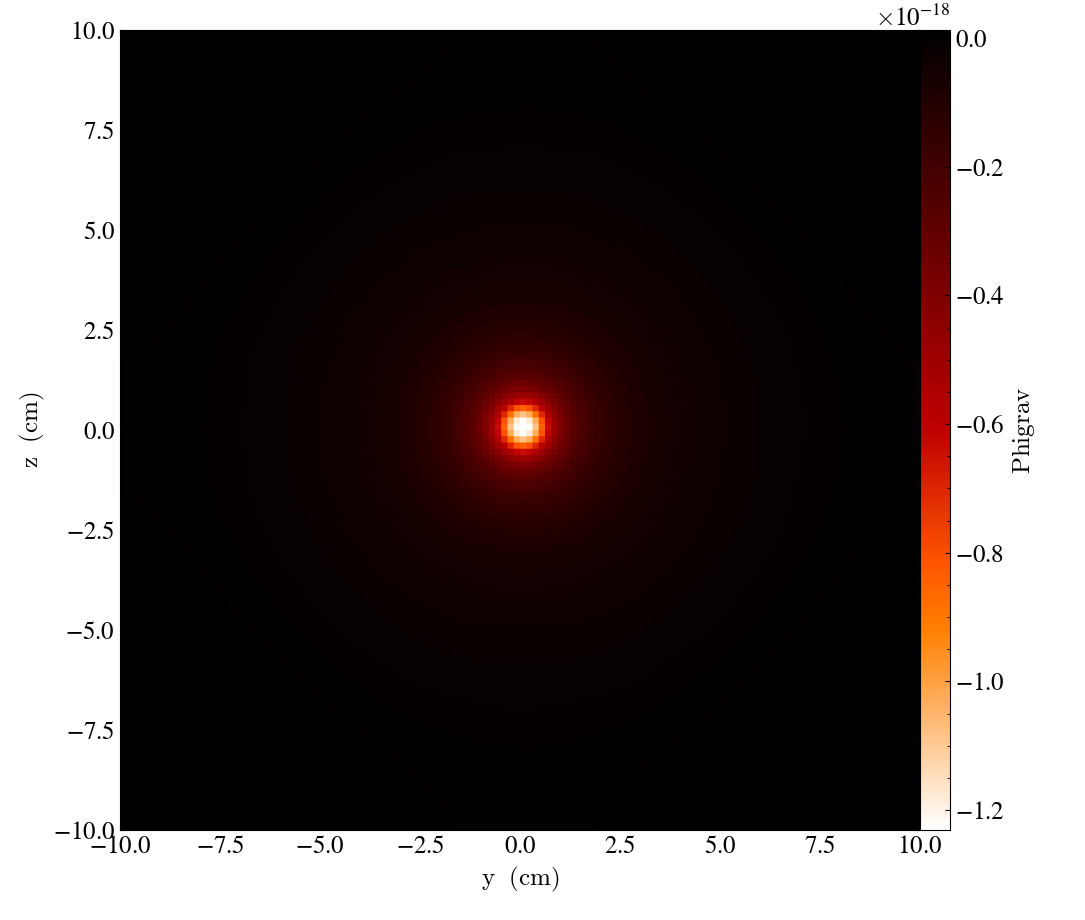

In [136]:
sl2.set_log("PhiGrav",False)
sl2.set_cmap(("PhiGrav"), "gist_heat_r")
sl2

In [39]:
sl2.save()

yt : [INFO     ] 2026-07-20 10:34:19,373 Saving plot plt00000_Slice_z_PhiGrav.png


['plt00000_Slice_z_PhiGrav.png']

yt : [INFO     ] 2026-07-17 16:23:38,531 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-07-17 16:23:38,532 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-07-17 16:23:38,535 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-07-17 16:23:38,535 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-07-17 16:23:38,536 Making a fixed resolution buffer of (('boxlib', 'KGfpr')) 800 by 800



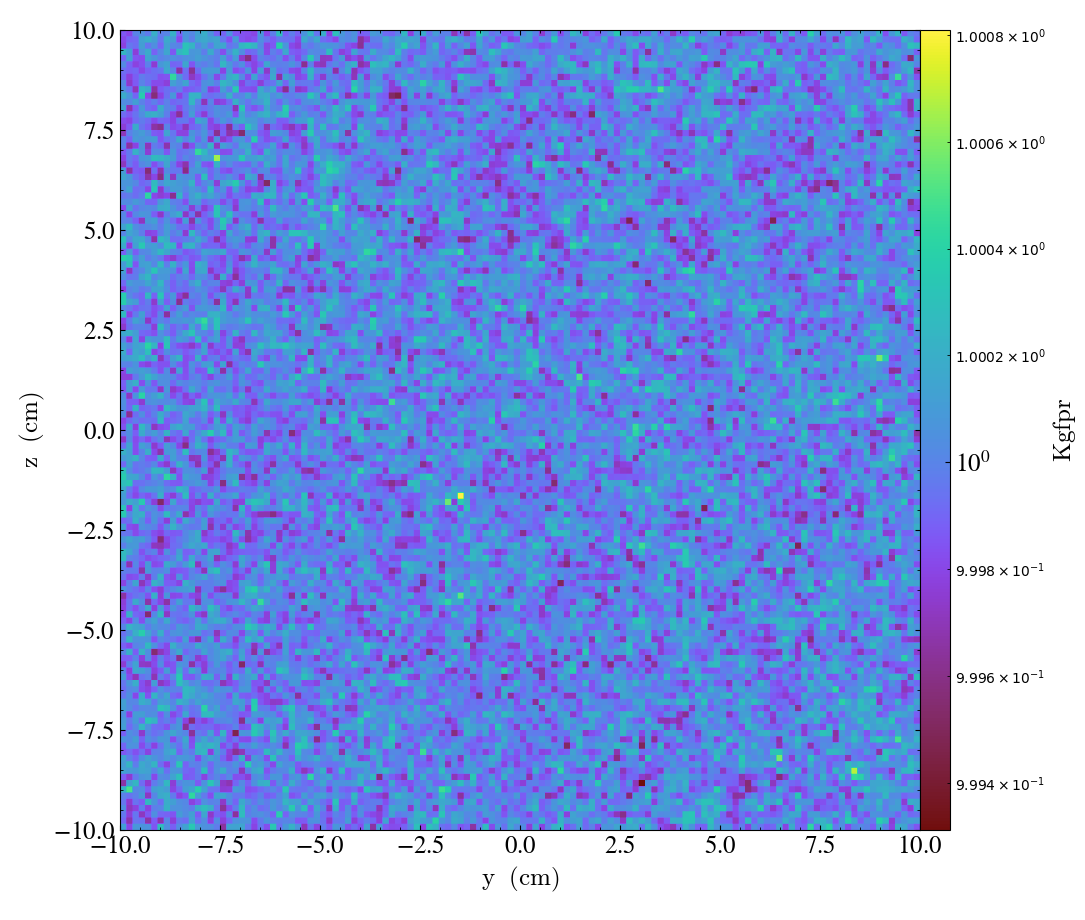

In [30]:
sl3 = yt.SlicePlot(ds, 0, ('boxlib', 'KGfpr'))
sl3

In [64]:
data0 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])
print(data0["boxlib","KGfpr"])
data = data0["boxlib","KGfpr"]

[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]] dimensionl

In [9]:
N=512
L = 80

def incr(n):
    if n == N-1:
        return 0
    else:
        return n + 1

def decr(n):
    if n == 0:
        return N-1
    else:
        return n - 1

In [ ]:
grad_phi = np.zeros((N,N,N))
for i in range(N):
    for j in range(N):
        for k in range(N):
            grad_phi[i,j,k] = ((data[incr(i),j,k] - data[decr(i),j,k]) ** 2 +
                               (data[i,incr(j),k] - data[i,decr(j),k]) ** 2 +
                               (data[i,j,incr(k)] - data[i,j,decr(k)]) ** 2
                               )
grad_phi /= 8 * (L / N) ** 2

IndexError: index 511 is out of bounds for axis 0 with size 128

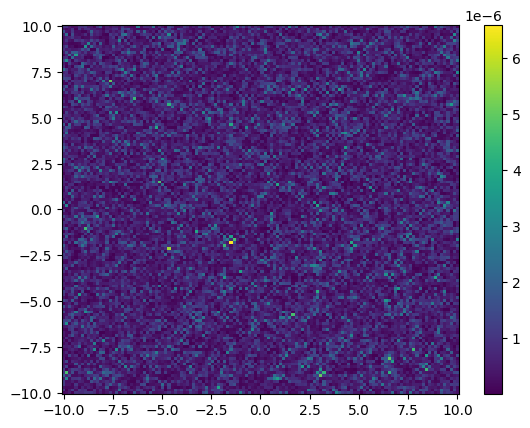

In [40]:
xs = np.linspace(-10,10,128)
x,y = np.meshgrid(xs,xs,indexing='ij')
plt.pcolormesh(x,y,grad_phi[64,:,:])
plt.colorbar()

Comparison of $\nabla^2 \Phi$ and $4\pi(\rho-\langle \rho \rangle)$

In [10]:
N=512
L = 80
rhs = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[N,N,N])["boxlib","KGfpr"]
#rhs -= np.mean(rhs)
#rhs *= 4 * np.pi

In [11]:
data = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[N,N,N])["boxlib","PhiGrav"]
lhs = np.zeros((N,N,N))
# for i in range(128):
#     for j in range(128):
#         for k in range(128):
#             lhs[i,j,k] = ((data[incr(i),j,k] - data[decr(i),j,k]) +
#                           (data[i,incr(j),k] - data[i,decr(j),k]) +
#                           (data[i,j,incr(k)] - data[i,j,decr(k)]) -
#                           6 * data[i,j,k]
#                          )
j,k=N//2,N//2
for i in range(N):
    lhs[i,N//2,N//2] = ((data[incr(i),j,k] + data[decr(i),j,k]) +
                  (data[i,incr(j),k] + data[i,decr(j),k]) +
                  (data[i,j,incr(k)] + data[i,j,decr(k)]) -
                  6 * data[i,j,k]
                 )
    lhs[N//2,i,N//2] = ((data[incr(i),j,k] + data[decr(i),j,k]) +
                  (data[i,incr(j),k] + data[i,decr(j),k]) +
                  (data[i,j,incr(k)] + data[i,j,decr(k)]) -
                  6 * data[i,j,k]
                 )
    lhs[N//2,N//2,i] = ((data[incr(i),j,k] + data[decr(i),j,k]) +
                  (data[i,incr(j),k] + data[i,decr(j),k]) +
                  (data[i,j,incr(k)] + data[i,j,decr(k)]) -
                  6 * data[i,j,k]
                 )
lhs /= (L / N) ** 2

In [12]:
sigma = 0.5
r = np.arange(-L//2, L//2, L/N)
r[N//2] = 1e-16   # Avoid division by zero
r2 = np.linspace(-L//2, L//2, 1000)
ampl = 0.0232524067

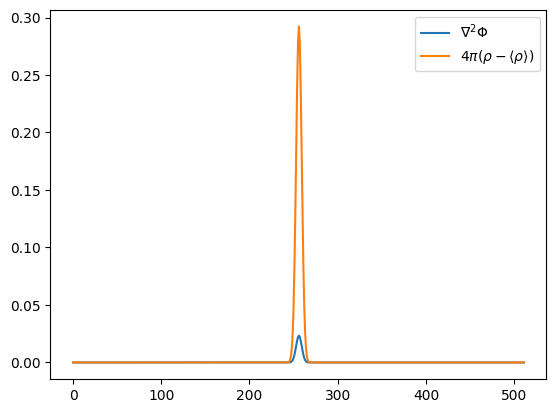

In [13]:
i,j,k = (N//2,N//2,N//2)

plt.plot(lhs[:,j,k], label=r"$\nabla^2 \Phi$")
plt.plot(4*np.pi*(rhs[:,j,k] - np.mean(rhs)), label=r"$4\pi (\rho - \langle \rho \rangle)$")
#plt.plot(-ampl * np.sqrt(np.pi/2) * sigma ** 3 / r * sp.special.erf(r / sigma / np.sqrt(2)))
#plt.plot(ampl*np.exp(-0.5 * r**2 / sigma ** 2), label = "Analytical")
plt.plot()
plt.legend()

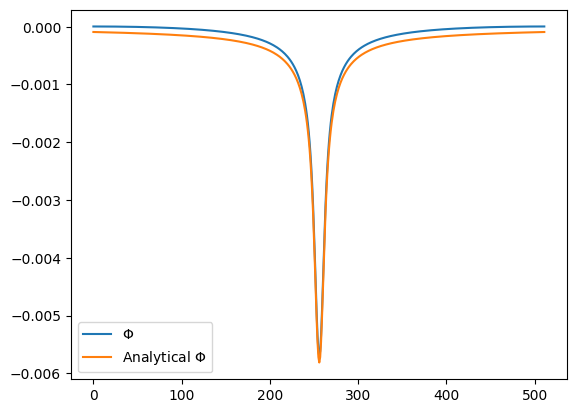

In [15]:
plt.plot(data[:,j,k], label=r"$\Phi$")
plt.plot(-ampl * np.sqrt(np.pi/2) * sigma ** 3 / r * sp.special.erf(r / sigma / np.sqrt(2)), label=r"Analytical $\Phi$")
plt.plot()
plt.legend()

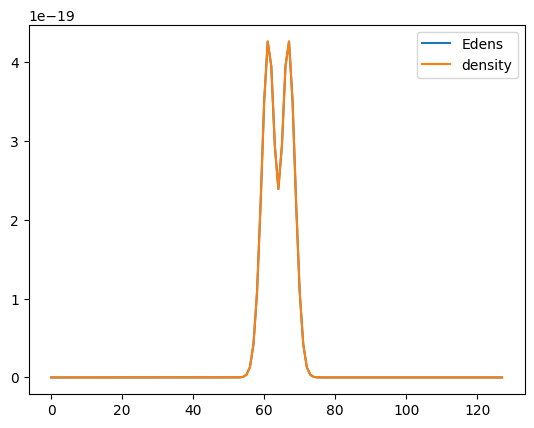

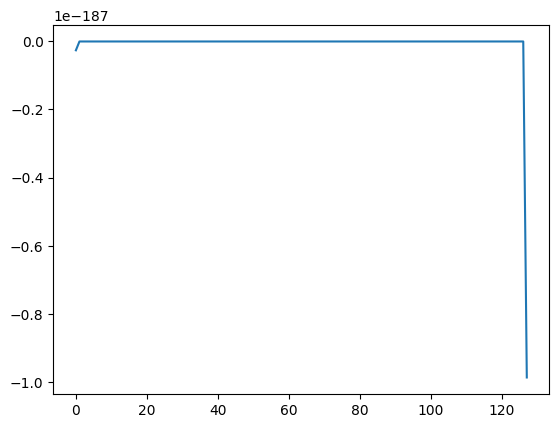

In [34]:
rhs1 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib","Edens"]
rhs2 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib","density"]
plt.plot(rhs1[:,j,k], label="Edens")
plt.plot(rhs2[:,j,k], label="density")
plt.legend()
plt.figure()
plt.plot(np.array(rhs1[:,j,k])-np.array(rhs2[:,j,k]))

<Figure size 640x480 with 0 Axes>

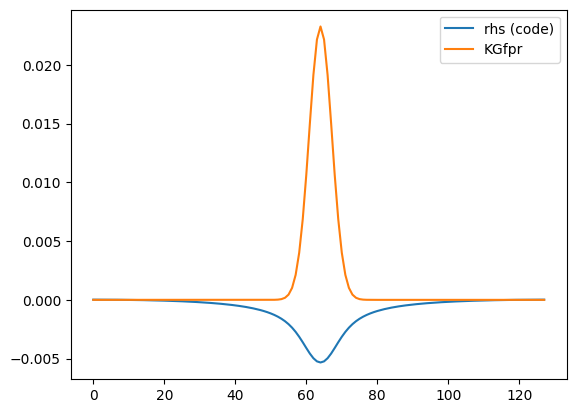

<Figure size 640x480 with 0 Axes>

In [17]:
rhs1 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib","PhiGrav"]
rhs2 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib","KGfpr"]
plt.plot(rhs1[:,64,64], label="rhs (code)")
plt.plot(rhs2[:,64,64], label="KGfpr")
plt.legend()
plt.figure()